In [2]:
import numpy as np 
import yfinance as yf
import pandas as pd
from scipy.optimize import minimize

In [7]:
# Diversified selection of 20 companies
tickers = ["MSFT", "NVDA", "JPM", "V", "LLY", "JNJ", "AMZN", "TSLA", "WMT", "KO", "GOOGL", "META", "XOM", "CVX", "GE", "CAT", "RIO", "NEE", "AMT", "BRK-B"]

# 5 years of daily closing price data adjusted for splits and dividends
data = yf.download(tickers, period="5y", auto_adjust=False)["Adj Close"]

# Daily return of each stock
daily_returns = ((data-data.shift(1))/data.shift(1)).dropna() # Drop the first data point since there is no previous day's data

print("There are " + str(daily_returns.shape[1]) + " stocks with daily returns tabulated over " + str(daily_returns.shape[0]) + " trading days from March 16, 2021 to March 13, 2026.")
print('The 20 ticker symbols are: ' + str(data.columns.tolist()))

[*********************100%***********************]  20 of 20 completed

There are 20 stocks with daily returns tabulated over 1255 trading days from March 16, 2021 to March 13, 2026.
The 20 ticker symbols are: ['AMT', 'AMZN', 'BRK-B', 'CAT', 'CVX', 'GE', 'GOOGL', 'JNJ', 'JPM', 'KO', 'LLY', 'META', 'MSFT', 'NEE', 'NVDA', 'RIO', 'TSLA', 'V', 'WMT', 'XOM']


<Axes: title={'center': 'Growth of $1: Bottom 5 Performers'}, xlabel='Date'>

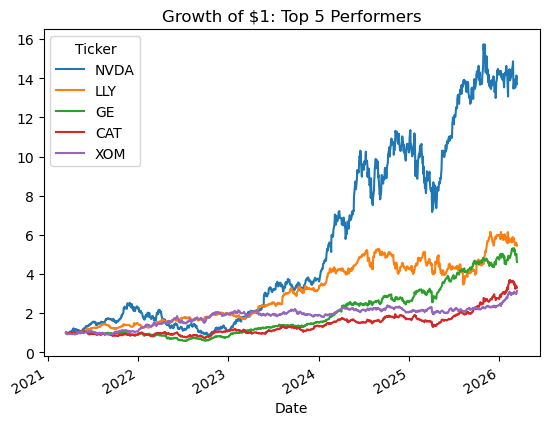

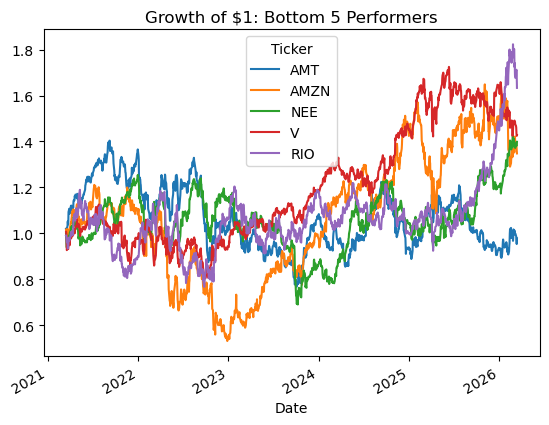

In [8]:
# Compounded daily growth of each stock over the 5-year period
cumulative_returns = (1 + daily_returns).cumprod(axis='index')

# Plot top 5 and bottom 5 performers
top_5 = cumulative_returns.iloc[-1].nlargest(5).index # Largest compounded growth of $1 over the 5-year period on the last trading day
bottom_5 = cumulative_returns.iloc[-1].nsmallest(5).index # Smallest compounded growth of $1 over the 5-year period on the last trading day

cumulative_returns[top_5].plot(title="Growth of $1: Top 5 Performers")
cumulative_returns[bottom_5].plot(title="Growth of $1: Bottom 5 Performers")

In [9]:
# Parameter estimation for µ (mean return vector) and V (covariance matrix)

# Convert dataframe object to numpy array object
daily_return_matrix = daily_returns.to_numpy()

number_of_stocks = daily_return_matrix.shape[1]
num_data_points = daily_return_matrix.shape[0]

# Mean return vector, µ
µ = np.mean(daily_return_matrix, axis=0) # Mean over the rows (trading days)

# Covariance matrix, V
excess_daily_return = daily_return_matrix - µ.T # Excess daily return (or loss) of each stock over its mean return
V = np.dot(excess_daily_return.T, excess_daily_return)/(num_data_points-1) # Sample 


In [10]:
# Portfolio variables, objective function, and constraints for the optimization

# Portfolio variables
initial_weights = np.ones((number_of_stocks,))/number_of_stocks # Each stock is given a portfolio allocation, as a fraction. Initializing weights equally and to sum to 1

# Objective function is portfolio variance, it is minimized
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights  

# Optimization constraints
bounds = tuple((0,1) for _ in range(number_of_stocks)) # Only long positions can be held for each stock 

minimum_desired_daily_return = 0.125/251 # Divide expected annualized return of 12.5% by the average number of trading days in a year

constraints = [{'type': 'ineq', 'fun': lambda w: np.dot(µ,w)-minimum_desired_daily_return}, # Daily portfolio return must be at least minimum desired daily return
               {'type': 'eq', 'fun': lambda w: np.sum(w)-1}] # Sum of fractions of positions must be 1

# Portfolio optimization
optimized_portfolio = minimize(fun=portfolio_variance, 
                               x0=initial_weights, 
                               args=(V,), 
                               bounds=bounds,
                               method='SLSQP',
                               constraints=constraints,
                               tol=1e-10,
                               options={'ftol': 1e-10,
                                        'maxiter': 1000})

cleaned_weights = None

if optimized_portfolio.success:
    cleaned_weights = optimized_portfolio.x
    
    cleaned_weights[cleaned_weights<1e-12] = 0 # Set any weight smaller than a negligible position to 0

    cleaned_weights = cleaned_weights/np.sum(cleaned_weights) # Normalize positions so they sum to 1
    
    optimal_weights = pd.Series(cleaned_weights, index=data.mean().index)
    print("Optimized Portfolio Weights:\n" + str(optimal_weights))
    
else:
    print("Not optimal")


Optimized Portfolio Weights:
Ticker
AMT      0.000000
AMZN     0.000000
BRK-B    0.063459
CAT      0.000830
CVX      0.051036
GE       0.014309
GOOGL    0.017990
JNJ      0.283955
JPM      0.006376
KO       0.245831
LLY      0.020949
META     0.000000
MSFT     0.082522
NEE      0.000880
NVDA     0.000000
RIO      0.040859
TSLA     0.000000
V        0.008268
WMT      0.116201
XOM      0.046535
dtype: float64


In [11]:
# Sharpe ratio and optimized portfolio return 

if optimized_portfolio.success:
    
      risk_free_rate = 0.037/251 # Divide current 3-month US treasury bill yield by the average number of trading days in a year

      optimized_portfolio_variance = cleaned_weights.T @ V @ cleaned_weights # Minimized portfolio variance using cleaned weights

      daily_sharpe_ratio = (np.dot(µ,cleaned_weights) - risk_free_rate)/np.sqrt(optimized_portfolio_variance) 

      annualized_sharpe_ratio = daily_sharpe_ratio*np.sqrt(251) # Annualize daily Sharpe ratio, scales by sqrt of the number of trading days

      annualized_portfolio_return = np.dot(µ,cleaned_weights)*251*100 # Scales by the number of trading days and 100 to convert to a percentage

      print("The annualized return for the optimized long-only portfolio is " + str(np.round(annualized_portfolio_return,2)) 
            + "%. The corresponding Sharpe ratio is " + str(np.round(annualized_sharpe_ratio,2)) + ".")

The annualized return for the optimized long-only portfolio is 16.36%. The corresponding Sharpe ratio is 1.08.
